# Extract 2D and 1D spectra

Use `gelsa` to load Euclid data!

In [5]:
import os
import numpy as np
from matplotlib import pyplot as plt
from gelsa.sgs import datastore
import gelsa
from gelsa import Gelsa
from gelsa import analysis

import astropy
import warnings
from astropy.io import fits
from astropy.table import Table, unique

from gelsa import visu

### Load the FULL EDFN_deep catalog with *redshift* measurements

In [6]:
warnings.filterwarnings('ignore', category=astropy.units.UnitsWarning, append=True)

DS = datastore.DataStore(# password_file='gelsa-extract-cosmos/.password',
                         # alternatively set username and password (can be empty string for local only)
                         username='', password='',
                         cachedir='/scratch/extra/ELSA/benjamin.granett/datastorecache'
                         )

area_list = {}

"""
# TR1 South
patch_id_list = [62, 67,71,74,78,107,111,115,123,126]
patch_id_list.sort()
"""

# EDFN North
patch_id_list = [38, 49, 57, 64, 99, 114, 151, 171]

# for patch_id in patch_id_list:
#    cat = DS.load_sel_catalog('EDFN_WIDE_SEL_R1',
#                              PatchId=patch_id,
#                              project='EUCLID',
#                              download_only=True
#                              )

cat = DS.load_sel_catalog('EDFN_DEEP_SEL_R1',
                          project='EUCLID',
                          CatalogOrigin='MEASURED_DEEP',
                         )

got username `` and password ***
EDFN_DEEP_SEL_R1 DpdLE3IDSELIDCatalog MEASURED_DEEP EUCLID None None
loaded /scratch/extra/ELSA/benjamin.granett/datastorecache/EUCLID/EDFN_DEEP_SEL_R1/DpdLE3IDSELIDCatalog/MEASURED_DEEP/cachecat_fb5b7bd09011bf3b32a5b6e1b4a8144f1075cd760f076a3b8a175bc719a68460.fits total rows 2749694


In [7]:
cat[:10]

OBJECT_ID,TILE_INDEX,RIGHT_ASCENSION,DECLINATION,SPE_Z,SPE_Z_ERR,SPE_Z_REL,SPE_Z_PROB,SPE_SUBCLASS,SPE_CONT_SNR,SEL_Z_FLAG,VIS_DET,FLUX_VIS_PSF,FLUX_Y_TEMPLFIT,FLUX_J_TEMPLFIT,FLUX_H_TEMPLFIT,FLUXERR_VIS_PSF,FLUXERR_Y_TEMPLFIT,FLUXERR_J_TEMPLFIT,FLUXERR_H_TEMPLFIT,FLUX_LYA,FLUX_OII3727,FLUX_HBETA,FLUX_OIII4960,FLUX_OIII5008,FLUX_HALPHA_TOT,FLUX_SII6732_TOT,FLUX_SIII9068,FLUX_SIII9530,FLUX_LYA_ERROR,FLUX_OII3727_ERROR,FLUX_HBETA_ERROR,FLUX_OIII4960_ERROR,FLUX_OIII5008_ERROR,FLUX_HALPHA_TOT_ERROR,FLUX_SII6732_TOT_ERROR,FLUX_SIII9068_ERROR,FLUX_SIII9530_ERROR,SNR_LYA,SNR_OII3727,SNR_HBETA,SNR_OIII4960,SNR_OIII5008,SNR_HALPHA_TOT,SNR_SII6732_TOT,SNR_SIII9068,SNR_SIII9530,FWHM_LYA,FWHM_OII3727,FWHM_HBETA,FWHM_OIII4960,FWHM_OIII5008,FWHM_HALPHA,FWHM_SII6732,FWHM_SIII9068,FWHM_SIII9530,QUAL_LYA,QUAL_OII3727,QUAL_HBETA,QUAL_OIII4960,QUAL_OIII5008,QUAL_HALPHA_TOT,QUAL_SII6732_TOT,QUAL_SIII9068,QUAL_SIII9530,FLUX_VIS_PSF_MWCORR,FLUX_Y_TEMPLFIT_MWCORR,FLUX_J_TEMPLFIT_MWCORR,FLUX_H_TEMPLFIT_MWCORR,FLUX_LYA_MWCORR,FLUX_OII3727_MWCORR,FLUX_HBETA_MWCORR,FLUX_OIII4960_MWCORR,FLUX_OIII5008_MWCORR,FLUX_HALPHA_TOT_MWCORR,FLUX_SII6732_TOT_MWCORR,FLUX_SIII9068_MWCORR,FLUX_SIII9530_MWCORR,SEGMENTATION_AREA,SEMIMAJOR_AXIS,SEMIMAJOR_AXIS_ERR,POSITION_ANGLE,POSITION_ANGLE_ERR,ELLIPTICITY,ELLIPTICITY_ERR,KRON_RADIUS,KRON_RADIUS_ERR,MU_MAX,MUMAX_MINUS_MAG,BINARY_FLAG,POINT_LIKE_FLAG,POINT_LIKE_PROB,EXTENDED_FLAG,EXTENDED_PROB,SPURIOUS_FLAG,SPURIOUS_PROB,DET_QUALITY_FLAG,FLAG_VIS,FLAG_Y,FLAG_J,FLAG_H,FLAG_NIR_STACK,VMPZ_COV_VIS,VMPZ_COV_Y,VMPZ_COV_J,VMPZ_COV_H,VMPZ_NOISE_VIS,VMPZ_NOISE_Y,VMPZ_NOISE_J,VMPZ_NOISE_H,PHOT_WEIGHT,GAL_EBV,SPE_GAL_PROB,SPE_STAR_PROB,SPE_QSO_PROB,SPE_CLASS,SPE_GRISM,SPE_N_DITH_RED_L,SPE_N_DITH_RED_M,SPE_N_DITH_RED_H,SPE_N_DITH_BLUE_L,SPE_N_DITH_BLUE_M,SPE_N_DITH_BLUE_H,SPE_N_DITH_HALPHA,SPE_N_DITH_OIII5008,SPE_W_MIN,SPE_W_MAX,SPE_NPIX,SPE_LSF,SPE_Z_REDUCED_CHI2,SPE_Z_CONT_REDUCED_CHI2,SPE_Z_P_VALUE,SPE_Z_CONT_P_VALUE,SPE_Z_RESIDUAL_NORMALITY,SPE_Z_CONT_RESIDUAL_NORMALITY,SPE_VEL_DISP_E,SPE_Z_1,SPE_Z_REL_1,SPE_Z_PROB_1,SPE_Z_2,SPE_Z_REL_2,SPE_Z_PROB_2,SPE_Z_3,SPE_Z_REL_3,SPE_Z_PROB_3,ASYMMETRY,ASYMMETRY_ERR,CONCENTRATION,CONCENTRATION_ERR,DISK_SERSIC_FLAGS,DISK_SERSIC_ITERATIONS,FLUXERR_G_EXT_HSC_1FWHM_APER,FLUXERR_G_EXT_HSC_SERSIC,FLUXERR_H_1FWHM_APER,FLUXERR_H_SERSIC,FLUXERR_I2_EXT_HSC_1FWHM_APER,FLUXERR_I2_EXT_HSC_SERSIC,FLUXERR_I_EXT_HSC_1FWHM_APER,FLUXERR_I_EXT_HSC_SERSIC,FLUXERR_J_1FWHM_APER,FLUXERR_J_SERSIC,FLUXERR_NIR_STACK_1FWHM_APER,FLUXERR_R2_EXT_HSC_1FWHM_APER,FLUXERR_R2_EXT_HSC_SERSIC,FLUXERR_R_EXT_HSC_1FWHM_APER,FLUXERR_R_EXT_HSC_SERSIC,FLUXERR_VIS_1FWHM_APER,FLUXERR_VIS_SERSIC,FLUXERR_Y_1FWHM_APER,FLUXERR_Y_SERSIC,FLUXERR_Z_EXT_HSC_1FWHM_APER,FLUXERR_Z_EXT_HSC_SERSIC,FLUX_DETECTION_TOTAL,FLUX_G_EXT_HSC_1FWHM_APER,FLUX_G_EXT_HSC_SERSIC,FLUX_H_1FWHM_APER,FLUX_H_SERSIC,FLUX_I2_EXT_HSC_1FWHM_APER,FLUX_I2_EXT_HSC_SERSIC,FLUX_I_EXT_HSC_1FWHM_APER,FLUX_I_EXT_HSC_SERSIC,FLUX_J_1FWHM_APER,FLUX_J_SERSIC,FLUX_NIR_STACK_1FWHM_APER,FLUX_R2_EXT_HSC_1FWHM_APER,FLUX_R2_EXT_HSC_SERSIC,FLUX_RADIUS,FLUX_RADIUS_ERR,FLUX_R_EXT_HSC_1FWHM_APER,FLUX_R_EXT_HSC_SERSIC,FLUX_VIS_1FWHM_APER,FLUX_VIS_SERSIC,FLUX_Y_1FWHM_APER,FLUX_Y_SERSIC,FLUX_Z_EXT_HSC_1FWHM_APER,FLUX_Z_EXT_HSC_SERSIC,GINI,GINI_ERR,MOMENT_20,MOMENT_20_ERR,SERSIC_ANGLE,SERSIC_ANGLE_ERR,SERSIC_EXT_DURATION,SERSIC_EXT_FLAGS,SERSIC_EXT_ITERATIONS,SERSIC_EXT_REDUCED_CHI2,SERSIC_SERSIC_NIR_AXIS_RATIO,SERSIC_SERSIC_NIR_AXIS_RATIO_ERR,SERSIC_SERSIC_NIR_INDEX,SERSIC_SERSIC_NIR_INDEX_ERR,SERSIC_SERSIC_NIR_RADIUS,SERSIC_SERSIC_NIR_RADIUS_ERR,SERSIC_SERSIC_VIS_AXIS_RATIO,SERSIC_SERSIC_VIS_AXIS_RATIO_ERR,SERSIC_SERSIC_VIS_INDEX,SERSIC_SERSIC_VIS_INDEX_ERR,SERSIC_SERSIC_VIS_RADIUS,SERSIC_SERSIC_VIS_RADIUS_ERR,SERSIC_VISNIR_DURATION,SERSIC_VISNIR_FLAGS,SERSIC_VISNIR_ITERATIONS,SERSIC_VISNIR_REDUCED_CHI2,SMOOTHNESS,SMOOTHNESS_ERR,SPE_Z_ERR_1,SPE_Z_ERR_2,SPE_Z_ERR_3,SPE_SUBCLASS_1,SPE_SUBCLASS_2,SPE_SUBCLASS_3,SPE_CONT_SNR_1,SPE_CONT_SNR_2,SPE_CONT_SNR_3,FLUX_ALIII1854,FLUX_ALIII1862,FLUX_ARII

In [8]:
# Partial EDFN catalog
filename = "/scratch/astro/nicolo.fiaba/EDFN_deep.fits"
hdu_list = fits.open(filename, memmap=True)
data = Table(hdu_list[1].data)

## Initialize Gelsa and Datastore

In [9]:
DS = datastore.DataStore(username='', password='',
                        cachedir='/scratch/astro/benjamin.granett/datastore'
                        )

got username `` and password ***


In [10]:
file_list = DS.load_sir_pack("DR1_R1", pointing_id_list=[30399])

DpdSirScienceFrame {'ppo_id': None, 'subsample_name': None, 'tile_index': None, 'pointing_id': 30399, 'detector_id': None, 'filter': None, 'plan_id': None, 'fields': None}
key='pointing_id_30399'
got len(path_hits)=2


In [11]:
G = gelsa.Gelsa(config_file="/scratch/astro/nicolo.fiaba/gelsa-spectra/calib/gelsa_config.json", 
                calibdir="/scratch/astro/nicolo.fiaba/gelsa-spectra/calib/", zero_order_catalog=None)

## Load SIR science frame

In [12]:
# Load the frame. Median filtering will be applied to subtract the continuum in the 2D image
frame = G.load_frame(**file_list[0], apply_median_filter=True)

loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Opt_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000000-MT0S7VWE-20250123-180643-0-new_opt_cal-0.xml
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/EUC_SIR_DETMODEL_REAL_DATA_OP_02.csv
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Ids_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000001-GQLJE83P-20250211-181132-0-new_ids_calib-0.xml
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Crv_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000001-6NJP8VE4-20250211-163247-0-new_crv_cal-0.xml


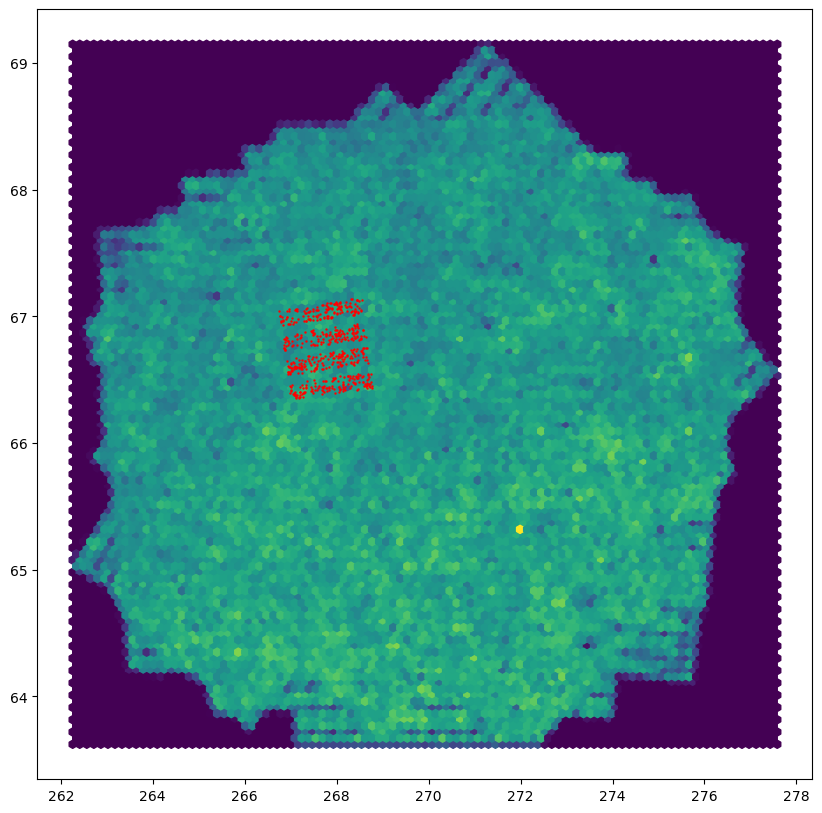

In [44]:
plt.figure(figsize=(10,10))
plt.hexbin(cat["RIGHT_ASCENSION"], cat['DECLINATION'])
plt.scatter(data_on_frame["RIGHT_ASCENSION"], data_on_frame['DECLINATION'], s=0.5, c='red')

In [13]:
x1, y1, det1 = frame.radec_to_pixel(cat["RIGHT_ASCENSION"], 
                                    cat['DECLINATION'], 
                                    wavelength=12000)
x2, y2, det2 = frame.radec_to_pixel(cat["RIGHT_ASCENSION"], 
                                    cat['DECLINATION'], 
                                    wavelength=19000)

### Source selection
- Full spectrum on one single detector (this can probably be relaxed) on the loaded frame
- Redshift between 0.9 and 1.8, so that $H_\alpha$ falls in NISP red grism frequency band
- $H_\alpha$ flux larger that $5 \times 10^{-16}$

In [38]:
on_frame_mask = (det1 == det2) & (det1 != -1) & (det2 != -1)

In [39]:
# Select only the sources whose spectrum is entirely on the loaded frame!
print(len(cat), "sources")
data_on_frame = cat[on_frame_mask]
print(len(data_on_frame), "sources on the frame with full spectrum in one detector")

# Select redshifts between 0.9 and 1.8
z_mask = (data_on_frame['SPE_Z'] > 0.9) & (data_on_frame['SPE_Z'] < 1.8)
data_on_frame = data_on_frame[z_mask]
print(len(data_on_frame), "sources with redshift between 0.9 and 1.8")

# Select bright enough sources -> good redshift measurements
h_alpha_mask = data_on_frame['FLUX_HALPHA_TOT_MWCORR'] > 5e-16
data_on_frame = data_on_frame[h_alpha_mask]
print(len(data_on_frame), "sources with H_alpha flux above 5e-16")
spe_z = data_on_frame['SPE_Z']

2749694 sources
38357 sources on the frame with full spectrum in one detector
10921 sources with redshift between 0.9 and 1.8
594 sources with H_alpha flux above 5e-16


# Extract spectrum

This function should be added to gelsa.analysis!

In [16]:
options = dict(
    # wave_range=(9000, 14000),  # blue grism!
    wave_range=(12000, 19000), # red grism
    wave_step=10.,
    extraction_window_pix=20,
    # extraction_sigma_arcsec=3,
    ndrops=1000,
    pixel_shrink=1,
    # use_inv_var_weight=False,
    # extraction_profile='gauss',
    use_rel_flux_calib=True,
    super_sample=1,
    # median_filter_size_pix=40,
    # apply_median_filter=True,
    # apply_persistence_correction=False,
    # persistence_mask_threshold=0,
)

def extract(frame, ra, dec):
    """ """
    spec2d, spec2d_var, spec2d_n, spec2d_pix_bins = frame.resample_on_wavelength(ra, dec, **options)
    spec2d_counts = spec2d_n > 0

    valid = spec2d_n > 0
    out = np.zeros(spec2d.shape)
    out_var = np.zeros(spec2d.shape)
    out[valid] = spec2d[valid]/spec2d_n[valid]
    out_var[valid] = spec2d_var[valid]/spec2d_n[valid]**2

    spec_pack = {
            'spec2d': out,
            'spec2d_var': out_var,
            'spec2d_norm': spec2d_n,
            'spec2d_counts': spec2d_counts,
            'wave_bins': spec2d_pix_bins[1],
            'pix_bins': spec2d_pix_bins[0],
            }
   
    pix_perp = (spec2d_pix_bins[0][1:] + spec2d_pix_bins[0][:-1])/2.
    wave = (spec2d_pix_bins[1][1:] + spec2d_pix_bins[1][:-1])/2.

    spec_pack['pixel_perp'] = pix_perp
    spec_pack['wavelength'] = wave
    
    spec1d_pack = analysis.Analysis.extract_spec2d_to_1d(spec_pack, pix_scale=0.3)

    return spec1d_pack, spec_pack

In [17]:
n = 11
print("Selected source is on detector", det1[on_frame_mask][n])

Selected source is on detector 3


In [18]:
# define coordinates of target galaxy
ra = data_on_frame["RIGHT_ASCENSION"][n]
dec = data_on_frame["DECLINATION"][n]

# Choose z from the catalog !
redshift = spe_z[n]

# run extraction routine
spec1d_pack, spec2d_pack = extract(frame, ra, dec)

Applying median filter with size 40 pixels and tilt=4
theshold 80
Percentiles (95, 99, 99.5) [  87.83161964 1072.51689941 2327.3672583 ]
median artifact masked pixel fraction: 0.05312


In [19]:
spec2d_pack.update(spec1d_pack)
# Now spec2d_pack is the combined dictionary

# Give it an easier name
pack = spec2d_pack

"\nplt.imshow(spec2d, vmin=-50, vmax=50, \n           aspect=20,\n           extent=(wave[0], wave[-1], ybins[0], ybins[-1]),\n           cmap=plt.cm.plasma.with_extremes(bad='grey'))\n"

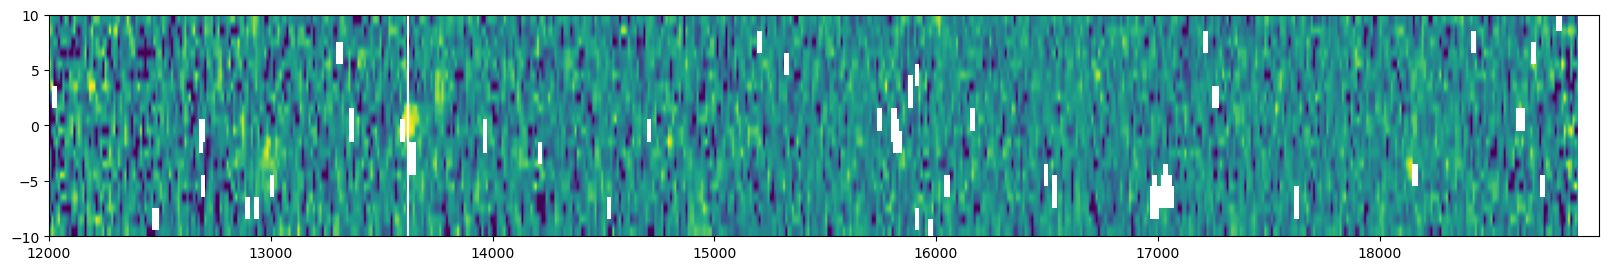

In [20]:
# plot the 2D spectrum
wave = pack['wave_bins']
ybins = pack['pix_bins']

plt.figure(figsize=(20, 3))

spec2d = pack['spec2d']
bad = pack['spec2d_norm'] == 0
spec2d[bad] = float('nan')

plt.imshow(visu.normalize_image(spec2d, levels=(5, 99.9)), origin='lower', aspect=50, 
          extent=(wave[0], wave[-1], ybins[0], ybins[-1]))
plt.axvline(6564*(1+redshift), c='white')
"""
plt.imshow(spec2d, vmin=-50, vmax=50, 
           aspect=20,
           extent=(wave[0], wave[-1], ybins[0], ybins[-1]),
           cmap=plt.cm.plasma.with_extremes(bad='grey'))
"""

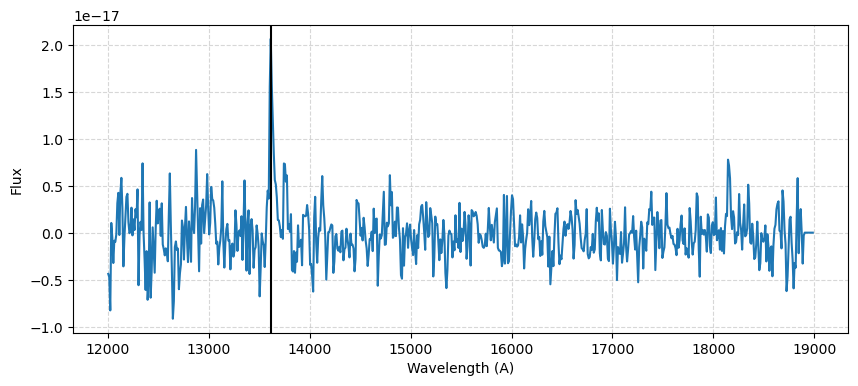

In [21]:
wave_bins = pack['wave_bins']
x = (wave_bins[1:]+wave_bins[:-1])/2.

plt.figure(figsize=(10,4))
plt.plot(x, pack['spec1d'])

# Visualize H-alpha
plt.axvline(6564*(1+redshift), c='k')

plt.xlabel("Wavelength (A)")
plt.ylabel("Flux")

plt.grid(True, alpha=0.5, ls='--')